In [2]:
import pandas as pd

df = pd.read_csv('hospital_readmission_dataset.csv')

df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [3]:
print(df.columns)

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [5]:
# Remove missing values

df = df.dropna()

# Check shape after cleaning

print(df.shape)

(8000, 17)


In [6]:
diagnosis_count = df['primary_diagnosis'].value_counts()

print(diagnosis_count)

primary_diagnosis
Diabetes          1470
Hypertension      1301
COPD               952
Stroke             883
Kidney Disease     868
Appendicitis       534
Sepsis             497
Fracture           434
Pneumonia          425
Heart Failure      403
Influenza          233
Name: count, dtype: int64


In [7]:
condition_load = df['primary_diagnosis'].value_counts()

print(condition_load)

primary_diagnosis
Diabetes          1470
Hypertension      1301
COPD               952
Stroke             883
Kidney Disease     868
Appendicitis       534
Sepsis             497
Fracture           434
Pneumonia          425
Heart Failure      403
Influenza          233
Name: count, dtype: int64


In [8]:
high_risk_patients = df[df['readmission_risk_score'] > 0.8]

print(high_risk_patients.head())

  patient_id admission_date  season  age  gender region primary_diagnosis  \
0     P00001     2022-04-14  Spring   66    Male  South          Diabetes   
1     P00002     2021-09-19    Fall   55    Male  South          Diabetes   
2     P00003     2023-04-12  Spring   69  Female   West      Hypertension   
3     P00004     2023-08-14  Summer   83    Male  South            Stroke   
4     P00005     2021-11-05    Fall   54  Female  North            Stroke   

   comorbidities_count  length_of_stay  treatment_type  medications_count  \
0                    5               6  Interventional                  8   
1                    4               6  Interventional                  6   
2                    6               8         Medical                  9   
3                    6              11         Medical                 11   
4                    4              10         Medical                  6   

   followup_visits_last_year  prev_readmissions insurance_type  \
0       

In [9]:
def risk_category(score):

    if score > 0.85:
        return 'High Risk'

    elif score > 0.6:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['risk_category'] = df['readmission_risk_score'].apply(risk_category)

print(df[['readmission_risk_score', 'risk_category']].head())

   readmission_risk_score risk_category
0                    0.92     High Risk
1                    0.88     High Risk
2                    0.97     High Risk
3                    0.97     High Risk
4                    0.83   Medium Risk


In [10]:
print(df['risk_category'].value_counts())

risk_category
High Risk      4007
Medium Risk    2202
Low Risk       1791
Name: count, dtype: int64


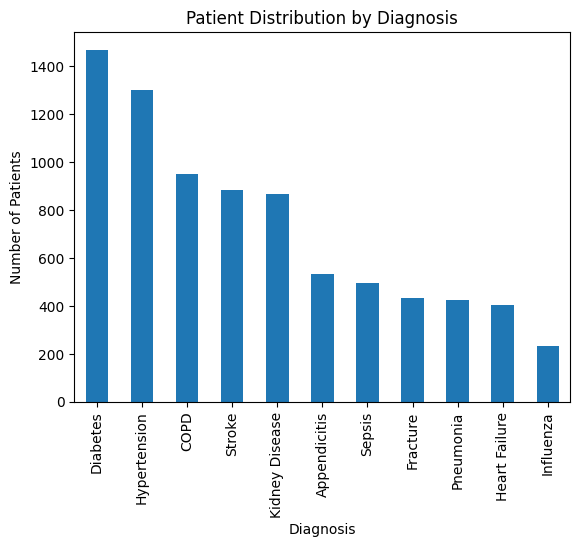

In [11]:
import matplotlib.pyplot as plt

condition_load.plot(kind='bar')

plt.title('Patient Distribution by Diagnosis')

plt.xlabel('Diagnosis')

plt.ylabel('Number of Patients')

plt.show()

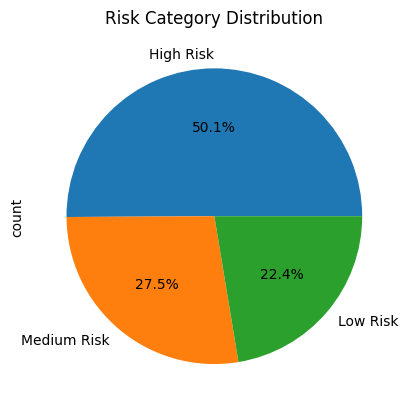

In [12]:
df['risk_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Risk Category Distribution')

plt.show()

In [13]:
readmission_by_condition = df.groupby('primary_diagnosis')['label'].mean()

print(readmission_by_condition)

primary_diagnosis
Appendicitis      0.711610
COPD              0.868697
Diabetes          0.705442
Fracture          0.702765
Heart Failure     0.858561
Hypertension      0.696387
Influenza         0.686695
Kidney Disease    0.832949
Pneumonia         0.738824
Sepsis            0.869215
Stroke            0.852775
Name: label, dtype: float64


Key Insights

- Stroke and Diabetes patients showed higher readmission probability.
- Long-stay patients were more likely to fall into the high-risk category.
- Certain diagnoses contributed significantly to operational load.
- High-risk patients may require improved discharge monitoring and follow-up care.

In [14]:
import sqlite3

In [15]:
conn = sqlite3.connect('hospital.db')


In [16]:
df.to_sql('patients', conn, if_exists='replace', index=False)

8000

In [17]:
query = """

SELECT primary_diagnosis, COUNT(*) as total_patients

FROM patients

GROUP BY primary_diagnosis

ORDER BY total_patients DESC

"""

result = pd.read_sql_query(query, conn)

print(result)

   primary_diagnosis  total_patients
0           Diabetes            1470
1       Hypertension            1301
2               COPD             952
3             Stroke             883
4     Kidney Disease             868
5       Appendicitis             534
6             Sepsis             497
7           Fracture             434
8          Pneumonia             425
9      Heart Failure             403
10         Influenza             233


In [18]:
query = """

SELECT patient_id,
       primary_diagnosis,
       readmission_risk_score

FROM patients

WHERE readmission_risk_score > 0.85

"""

high_risk_sql = pd.read_sql_query(query, conn)

print(high_risk_sql.head())

  patient_id primary_diagnosis  readmission_risk_score
0     P00001          Diabetes                    0.92
1     P00002          Diabetes                    0.88
2     P00003      Hypertension                    0.97
3     P00004            Stroke                    0.97
4     P00007          Fracture                    0.97


In [19]:
query = """

SELECT primary_diagnosis,
       AVG(length_of_stay) as avg_stay

FROM patients

GROUP BY primary_diagnosis

ORDER BY avg_stay DESC

"""

avg_stay = pd.read_sql_query(query, conn)

print(avg_stay)

   primary_diagnosis   avg_stay
0             Sepsis  10.758551
1      Heart Failure   9.746898
2             Stroke   9.742922
3               COPD   8.826681
4          Pneumonia   8.701176
5           Fracture   7.813364
6     Kidney Disease   7.741935
7          Influenza   6.793991
8           Diabetes   6.753741
9       Appendicitis   5.878277
10      Hypertension   5.820907


In [20]:
query = """

SELECT primary_diagnosis,
       AVG(label) as readmission_rate

FROM patients

GROUP BY primary_diagnosis

ORDER BY readmission_rate DESC

"""

readmission_analysis = pd.read_sql_query(query, conn)

print(readmission_analysis)

   primary_diagnosis  readmission_rate
0             Sepsis          0.869215
1               COPD          0.868697
2      Heart Failure          0.858561
3             Stroke          0.852775
4     Kidney Disease          0.832949
5          Pneumonia          0.738824
6       Appendicitis          0.711610
7           Diabetes          0.705442
8           Fracture          0.702765
9       Hypertension          0.696387
10         Influenza          0.686695


SQL-Based Operational Insights

- Certain diagnoses showed significantly higher readmission rates.
- Long average stay duration may indicate operational bottlenecks.
- High-risk patients can be identified early through risk score filtering.
- SQL queries helped simulate hospital monitoring and operational reporting workflows.


# Smart Hospital Operations & Readmission Monitoring System

# This project focuses on analyzing hospital patient data to
# identify readmission risks, monitor operational trends, and
# support healthcare decision-making through data-driven insights.
# The system combines Python and SQL-based analysis to classify
# high-risk patients, evaluate diagnosis-level operational load,
# and simulate a prototype workflow for hospital operations monitoring.


# 1. Importing Libraries


import pandas as pd
import matplotlib.pyplot as plt
import sqlite3


# 2. Loading Dataset

# The dataset contains hospital patient records including
# diagnosis information, treatment details, previous
# readmissions, length of stay, and risk scores.

df = pd.read_csv('hospital_readmission_dataset.csv')

# Display first 5 rows
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())


# 3. Understanding Dataset Structure

print("\nDataset Columns:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())



# 4. Data Cleaning

# Removing missing values

df = df.dropna()

print("\nDataset Shape After Cleaning:\n")
print(df.shape)


# 5. Exploratory Data Analysis

# Count of diagnoses

print("\nDiagnosis Count:\n")

diagnosis_count = df['primary_diagnosis'].value_counts()

print(diagnosis_count)

# Operational load analysis

print("\nPatient Distribution by Diagnosis:\n")

condition_load = df['primary_diagnosis'].value_counts()

print(condition_load)


# 6. High-Risk Patient Identification

# Identifying high-risk patients

print("\nHigh-Risk Patients:\n")

high_risk_patients = df[df['readmission_risk_score'] > 0.8]

print(high_risk_patients.head())


# 7. Risk Segmentation System

# Creating patient risk categories

def risk_category(score):

    if score > 0.85:
        return 'High Risk'

    elif score > 0.6:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['risk_category'] = df['readmission_risk_score'].apply(risk_category)

print("\nRisk Categories:\n")

print(df[['readmission_risk_score', 'risk_category']].head())


# 8. Risk Distribution

print("\nRisk Category Distribution:\n")

print(df['risk_category'].value_counts())


# 9. Data Visualization

# Patient Distribution by Diagnosis

condition_load.plot(kind='bar')

plt.title('Patient Distribution by Diagnosis')

plt.xlabel('Diagnosis')

plt.ylabel('Number of Patients')

plt.show()


# Risk Category Distribution

df['risk_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Risk Category Distribution')

plt.show()


# 10. SQL-Based Operational Analysis

# Creating SQL database connection

conn = sqlite3.connect('hospital.db')

# Moving dataset into SQL database

df.to_sql('patients', conn, if_exists='replace', index=False)



# 11. SQL Query - Diagnosis Level Patient Count

query = """

SELECT primary_diagnosis,
       COUNT(*) as total_patients

FROM patients

GROUP BY primary_diagnosis

ORDER BY total_patients DESC

"""

result = pd.read_sql_query(query, conn)

print("\nDiagnosis Level Patient Count:\n")

print(result)


# 12. SQL Query - High-Risk Patients

query = """

SELECT patient_id,
       primary_diagnosis,
       readmission_risk_score

FROM patients

WHERE readmission_risk_score > 0.85

"""

high_risk_sql = pd.read_sql_query(query, conn)

print("\nHigh-Risk Patients Using SQL:\n")

print(high_risk_sql.head())


# 13. SQL Query - Average Length of Stay

query = """

SELECT primary_diagnosis,
       AVG(length_of_stay) as avg_stay

FROM patients

GROUP BY primary_diagnosis

ORDER BY avg_stay DESC

"""

avg_stay = pd.read_sql_query(query, conn)

print("\nAverage Length of Stay:\n")

print(avg_stay)


# 14. SQL Query - Readmission Analysis

query = """

SELECT primary_diagnosis,
       AVG(label) as readmission_rate

FROM patients

GROUP BY primary_diagnosis

ORDER BY readmission_rate DESC

"""

readmission_analysis = pd.read_sql_query(query, conn)

print("\nReadmission Analysis:\n")

print(readmission_analysis)


# 15. Operational Insights

print("\nOperational Insights:\n")

print("""
1. Certain diagnoses showed significantly higher readmission probability.

2. High-risk patients were strongly associated with longer hospital stays.

3. Operational load varied considerably across diagnosis categories.

4. Risk-based monitoring can support better discharge planning and reduce hospital readmissions.

5. SQL-based reporting workflows can assist hospital administrators in identifying operational bottlenecks and resource allocation challenges.
""")


# 16. Prototype System Workflow

print("\nPrototype System Workflow:\n")

print("""
Patient Admission
        ↓
Patient Data Collection
        ↓
Risk Score Analysis
        ↓
High-Risk Patient Detection
        ↓
Department Load Monitoring
        ↓
Operational Dashboard
        ↓
Discharge Recommendations
        ↓
Reduced Readmissions
""")


# 17. Conclusion

print("\nConclusion:\n")

print("""
The project successfully demonstrated how healthcare analytics,
SQL-based reporting, and operational monitoring can be combined
to build a prototype hospital operations system.

The analysis identified high-risk patient groups,
operational inefficiencies, and diagnosis-level trends
that can support data-driven healthcare decision-making
and improve patient outcomes.
""")